# Urban Traffic Forecasting
**Ali Mehrabi · Budapest University of Technology and Economics**

This analysis compares LSTM, GRU and Conv1D next-hour forecasts using historical traffic alone and traffic combined with environmental noise. The experiment uses chronological evaluation and a persistence baseline.

**Execution:** the notebook runs from the repository root with `data/` beside it, using a Python 3.11 or 3.12 kernel. Setup instructions are provided in [README.md](README.md#reproducing-the-experiment). The complete pipeline is defined below; `forecasting.py` provides the equivalent command-line workflow.

The default run trains all six models for up to 50 epochs each. Training may take several minutes or longer on your machine. Epoch progress is printed. Results, charts and model checkpoints are regenerated in this folder.

In [1]:
# Run once if this kernel needs the packages, then restart the kernel:
# %pip install -r requirements.txt

## 1. Imports and configuration

A fixed seed makes runs easier to compare. Identical results across different hardware and library versions are not guaranteed. Computation uses the CPU, so no GPU setup is required.

In [2]:
"""Reproducible, one-step traffic forecasting experiment.

This cleaned implementation extends Ali Mehrabi's BME coursework notebook.
Run from the repository root with: python forecasting.py
"""
from __future__ import annotations

import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("OMP_NUM_THREADS", "2")
os.environ.setdefault("MPLBACKEND", "Agg")

import argparse
import json
import random
import platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import sklearn
import matplotlib
import joblib

ROOT = Path.cwd()
if not (ROOT / "data/traffic.csv").is_file():
    raise FileNotFoundError("Open this notebook from the extracted urban-traffic-forecasting folder. Keep the data folder beside it.")
WINDOW = 9
SEED = 42
COLORS = {"Traffic only": "#4169a1", "Traffic + noise": "#8056a2", "Baseline": "#687574"}



## 2. Data preparation

Traffic observations are selected from site 755, detector 1. Timestamps are parsed, conflicting duplicate readings are excluded and observations are aligned to an hourly grid. Recorded zero traffic counts are preserved. Input gaps are forward-filled for at most two hours using past readings; missing traffic targets remain unfilled. Incomplete input windows are excluded.

Nine actual hours predict the next hourly count. Date boundaries split the grid into 60% training, 20% validation and 20% test periods. Input and target scalers are fitted using training data only. Both feature variants use identical eligible targets. A later one-step test prediction can use earlier observed test hours.

No exponential smoothing is applied. These are processed coursework extracts; their full earlier processing history and timezone alignment are not independently verified. See `data/README.md` for attribution.

In [3]:
def prepare_data(root: Path = ROOT):
    """Build an hourly grid; never fill targets or use future observations."""
    raw_traffic = pd.read_csv(root / "data/traffic.csv", low_memory=False)
    raw_noise = pd.read_csv(root / "data/noise.csv", low_memory=False)
    required = {"Detector", "Site", "Sum_Volume", "datetime"}
    if not required.issubset(raw_traffic.columns):
        raise ValueError(f"Traffic CSV must contain {sorted(required)}")
    if not {"Date and Time", "LAeq"}.issubset(raw_noise.columns):
        raise ValueError("Noise CSV must contain Date and Time and LAeq")
    traffic = raw_traffic.loc[
        (pd.to_numeric(raw_traffic["Detector"], errors="coerce") == 1)
        & (pd.to_numeric(raw_traffic["Site"], errors="coerce") == 755)
    ].copy()
    noise = raw_noise.copy()
    for df, column in [(traffic, "datetime"), (noise, "Date and Time")]:
        df["timestamp"] = pd.to_datetime(df[column], format="%m/%d/%Y %H:%M", errors="coerce")
    invalid_dates = int(traffic.timestamp.isna().sum() + noise.timestamp.isna().sum())
    traffic = traffic.dropna(subset=["timestamp"])
    noise = noise.dropna(subset=["timestamp"])
    traffic["traffic"] = pd.to_numeric(traffic["Sum_Volume"], errors="coerce")
    noise["noise"] = pd.to_numeric(noise["LAeq"], errors="coerce")
    traffic.loc[traffic.traffic < 0, "traffic"] = np.nan
    noise.loc[noise.noise <= 0, "noise"] = np.nan
    duplicates = int(traffic.timestamp.duplicated().sum())
    # Conflicting duplicates have uncertain provenance: drop all readings at
    # that timestamp instead of choosing a value or inventing a daily total.
    traffic = traffic.set_index("timestamp")
    traffic = traffic.loc[~traffic.index.duplicated(keep=False), ["traffic"]]
    noise = noise.set_index("timestamp")
    noise = noise.loc[~noise.index.duplicated(keep=False), ["noise"]]
    start = max(traffic.index.min(), noise.index.min())
    end = min(traffic.index.max(), noise.index.max())
    hourly = pd.date_range(start, end, freq="h", name="timestamp")
    observed = traffic.join(noise, how="outer").reindex(hourly)
    features = observed.ffill(limit=2)
    # Real zero vehicle counts remain valid. No smoothing of evaluation targets.
    n = len(hourly)
    cut1, cut2 = int(n * 0.6), int(n * 0.8)
    if n < 100 or cut1 <= WINDOW:
        raise ValueError("At least 100 overlapping hourly timestamps are required")
    train_cutoff, test_cutoff = hourly[cut1], hourly[cut2]
    train_rows = features.iloc[:cut1].dropna()
    scaler_x = MinMaxScaler().fit(train_rows[["traffic", "noise"]])
    scaler_y = MinMaxScaler().fit(observed.iloc[:cut1][["traffic"]].dropna().to_numpy())
    scaled = scaler_x.transform(features[["traffic", "noise"]])
    inputs, targets, times = [], [], []
    for i in range(WINDOW, n):
        history = scaled[i-WINDOW:i]
        target = observed.traffic.iloc[i]
        # Exact 9-hour windows on the grid; both feature sets use identical rows.
        if np.isfinite(history).all() and pd.notna(target):
            inputs.append(history)
            targets.append(target)
            times.append(hourly[i])
    x = np.asarray(inputs, dtype=np.float32)
    y_raw = np.asarray(targets, dtype=np.float32)
    y = scaler_y.transform(y_raw.reshape(-1, 1)).astype(np.float32).ravel()
    times = pd.DatetimeIndex(times)
    masks = {
        "train": times < train_cutoff,
        "validation": (times >= train_cutoff) & (times < test_cutoff),
        "test": times >= test_cutoff,
    }
    if any(mask.sum() == 0 for mask in masks.values()):
        raise ValueError("Each chronological split needs usable forecasting windows")
    assert times[masks["train"]].max() < times[masks["validation"]].min()
    assert times[masks["validation"]].max() < times[masks["test"]].min()
    quality = {
        "raw_traffic_rows": len(raw_traffic),
        "selected_detector_rows_before_cleanup": int((pd.to_numeric(raw_traffic.Detector, errors="coerce") == 1).sum()),
        "noise_rows": len(raw_noise), "invalid_timestamp_rows": invalid_dates,
        "duplicate_traffic_rows_beyond_first": duplicates,
        "duplicate_timestamps_excluded": int(duplicates),
        "hourly_grid_rows": n,
        "missing_traffic_hours_before_forward_fill": int(observed.traffic.isna().sum()),
        "missing_noise_hours_before_forward_fill": int(observed.noise.isna().sum()),
        "start": str(start), "end": str(end),
        "validation_start": str(train_cutoff), "test_start": str(test_cutoff),
        "window_hours": WINDOW, "forecast_steps": 1,
        "usable_windows": {name: int(mask.sum()) for name, mask in masks.items()},
    }
    return {"observed": observed, "features": features, "x": x, "y": y,
            "y_raw": y_raw, "times": times, "masks": masks,
            "scaler_x": scaler_x, "scaler_y": scaler_y, "quality": quality}


def scores(y, prediction):
    errors = np.asarray(prediction) - np.asarray(y)
    return {"MAE": float(np.mean(np.abs(errors))),
            "RMSE": float(np.sqrt(np.mean(errors**2)))}



In [4]:
from IPython.display import display, Image, Markdown
prepared = prepare_data(ROOT)
display(pd.Series(prepared["quality"], name="Data checks").to_frame())
display(prepared["observed"].head())

,Data checks
raw_traffic_rows,45802
selected_detector_rows_before_cleanup,5725
noise_rows,5872
invalid_timestamp_rows,0
duplicate_traffic_rows_beyond_first,3
duplicate_timestamps_excluded,3
hourly_grid_rows,5725
missing_traffic_hours_before_forward_fill,6
missing_noise_hours_before_forward_fill,8
start,2022-05-01 01:00:00


,traffic,noise
timestamp,,
2022-05-01 01:00:00,65.0,61.5
2022-05-01 02:00:00,68.0,60.5
2022-05-01 03:00:00,110.0,59.4
2022-05-01 04:00:00,94.0,58.9
2022-05-01 05:00:00,40.0,59.0


## 3. Model architectures

| Model | Layers | Dropout after each main layer |
| --- | --- | --- |
| LSTM, traffic only | 64 → 32 units; Dense 8 → 1 | 40% |
| LSTM, traffic + noise | 64 → 32 units; Dense 8 → 1 | 30% |
| GRU, both variants | 64 → 32 units; Dense 8 → 1 | 30% |
| Conv1D, both variants | 64 → 32 filters, kernel 2, same padding; Flatten; Dense 8 → 1 | 30% |

**Comparison limitation:** the two LSTM variants have different dropout rates. Their comparison therefore changes both the input features and dropout; it does not isolate the effect of noise alone.

In [5]:
def build_model(tf, architecture, feature_count):
    layers = tf.keras.layers
    model = tf.keras.Sequential([layers.Input(shape=(WINDOW, feature_count))])
    if architecture in {"LSTM", "GRU"}:
        cell = layers.LSTM if architecture == "LSTM" else layers.GRU
        model.add(cell(64, return_sequences=True))
        dropout = 0.4 if architecture == "LSTM" and feature_count == 1 else 0.3
        model.add(layers.Dropout(dropout))
        model.add(cell(32))
        model.add(layers.Dropout(dropout))
    elif architecture == "Conv1D":
        model.add(layers.Conv1D(64, 2, activation="relu", padding="same"))
        model.add(layers.Dropout(0.3))
        model.add(layers.Conv1D(32, 2, activation="relu", padding="same"))
        model.add(layers.Dropout(0.3))
        model.add(layers.Flatten())
    else:
        raise ValueError(f"Unknown architecture: {architecture}")
    model.add(layers.Dense(8, activation="relu"))
    model.add(layers.Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss="mse", metrics=[tf.keras.metrics.RootMeanSquaredError()])
    return model



## 4. Training and evaluation functions

Training uses Adam with learning rate 0.001, MSE loss, a maximum of 50 epochs and batch size 32. Early stopping uses patience 5 and restores the best weights. The learning rate is halved after 3 epochs without validation improvement. The best checkpoint is saved for each model.

Training windows are shuffled, but the nine hours inside each window retain their order. The chronological splits remain fixed. The persistence baseline predicts the latest available traffic feature.

Model selection uses **validation RMSE**. Held-out test MAE and RMSE are reported after predictions are converted back to vehicle counts. All six test scores are reported; subsequent tuning should use validation data.

In [6]:
def run_experiment(root=ROOT, epochs=50, batch_size=32):
    import tensorflow as tf
    random.seed(SEED)
    np.random.seed(SEED)
    try:
        tf.config.threading.set_intra_op_parallelism_threads(2)
        tf.config.threading.set_inter_op_parallelism_threads(2)
    except RuntimeError:
        pass
    tf.keras.utils.set_random_seed(SEED)
    tf.config.experimental.enable_op_determinism()
    root = Path(root)
    data = prepare_data(root)
    for folder in ["results", "figures", "models"]:
        (root / folder).mkdir(exist_ok=True)
    (root / "results/data_quality.json").write_text(json.dumps(data["quality"], indent=2))
    joblib.dump({"input_scaler": data["scaler_x"], "target_scaler": data["scaler_y"],
                 "window_hours": WINDOW, "feature_order": ["traffic", "noise"]},
                root / "models/preprocessing.joblib")
    print(json.dumps(data["quality"], indent=2), flush=True)
    masks, rows, curves, predictions = data["masks"], [], {}, {}
    test_y = data["y_raw"][masks["test"]]
    persistence = data["features"].traffic.reindex(data["times"] - pd.Timedelta(hours=1)).to_numpy()
    rows.append({"Model": "Persistence", "Inputs": "Baseline", "Epochs": 0,
                 "Validation_RMSE": scores(data["y_raw"][masks["validation"]], persistence[masks["validation"]])["RMSE"],
                 **scores(test_y, persistence[masks["test"]])})
    predictions["Persistence"] = persistence[masks["test"]]
    options = tf.data.Options()
    options.threading.private_threadpool_size = 1
    options.threading.max_intra_op_parallelism = 1
    for inputs, feature_count in [("Traffic only", 1), ("Traffic + noise", 2)]:
        x = data["x"][:, :, :feature_count]
        for architecture in ["LSTM", "GRU", "Conv1D"]:
            tf.keras.backend.clear_session()
            tf.keras.utils.set_random_seed(SEED)
            name = f"{architecture} | {inputs}"
            print(f"Training {name} ...", flush=True)
            train = tf.data.Dataset.from_tensor_slices((x[masks["train"]], data["y"][masks["train"]]))
            train = train.shuffle(int(masks["train"].sum()), seed=SEED).batch(batch_size).with_options(options)
            val = tf.data.Dataset.from_tensor_slices((x[masks["validation"]], data["y"][masks["validation"]])).batch(batch_size).with_options(options)
            model = build_model(tf, architecture, feature_count)
            model_path = root / "models" / f"{architecture.lower()}_{feature_count}features.keras"
            history = model.fit(train, validation_data=val, epochs=epochs, verbose=2, shuffle=False, callbacks=[
                tf.keras.callbacks.ModelCheckpoint(str(model_path), monitor="val_loss", save_best_only=True),
                tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
                tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=3, factor=0.5),
            ])
            def predict(mask):
                ds = tf.data.Dataset.from_tensor_slices(x[mask]).batch(batch_size).with_options(options)
                return data["scaler_y"].inverse_transform(model.predict(ds, verbose=0)).ravel()
            validation_prediction = predict(masks["validation"])
            test_prediction = predict(masks["test"])
            row = {"Model": architecture, "Inputs": inputs,
                   "Epochs": len(history.history["loss"]),
                   "Validation_RMSE": scores(data["y_raw"][masks["validation"]], validation_prediction)["RMSE"],
                   **scores(test_y, test_prediction)}
            rows.append(row)
            predictions[name] = test_prediction
            curves[name] = history.history
            print(f"  validation RMSE={row['Validation_RMSE']:.2f}; test RMSE={row['RMSE']:.2f}", flush=True)
    (root / "results/training_history.json").write_text(json.dumps(curves, indent=2))
    results = pd.DataFrame(rows)
    # Select only by validation score, not by test-set performance.
    selected = results.iloc[results.Validation_RMSE.argmin()]
    selected_name = "Persistence" if selected.Model == "Persistence" else f"{selected.Model} | {selected.Inputs}"
    output = pd.DataFrame({"timestamp": data["times"][masks["test"]], "actual": test_y, **predictions})
    results.to_csv(root / "results/metrics.csv", index=False)
    output.to_csv(root / "results/test_predictions.csv", index=False)
    metadata = {"seed": SEED, "max_epochs": epochs, "batch_size": batch_size,
                "selected_by_validation": selected_name,
                "tensorflow": tf.__version__, "numpy": np.__version__, "pandas": pd.__version__,
                "python": platform.python_version(), "scikit_learn": sklearn.__version__, "matplotlib": matplotlib.__version__,
                "architectures": "Original: LSTM/GRU 64 then 32 units; Conv1D 64 then 32 filters; dense 8 then 1",
                "dropout": "LSTM traffic-only 0.4; all other variants 0.3; after both recurrent/convolution layers",
                "target": "raw observed vehicle count at next timestamp; no target smoothing"}
    (root / "results/run_config.json").write_text(json.dumps(metadata, indent=2))
    make_figures(data, results, output, curves, selected_name, root)
    return results, data["quality"], metadata



In [7]:
def make_figures(data, results, predictions, curves, selected_name, root):
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                         "axes.spines.top": False, "axes.spines.right": False,
                         "axes.titleweight": "bold", "figure.dpi": 130})
    observed = data["observed"].iloc[:24*7]
    fig, axes = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True)
    axes[0].plot(observed.index, observed.traffic, color=COLORS["Traffic only"])
    axes[0].set(title="A week of traffic and environmental noise", ylabel="Vehicles per hour")
    axes[1].plot(observed.index, observed.noise, color=COLORS["Traffic + noise"])
    axes[1].set(ylabel="Noise LAeq (dB)")
    fig.autofmt_xdate(); fig.tight_layout()
    fig.savefig(root / "figures/traffic_and_noise.png"); plt.close(fig)
    fig, ax = plt.subplots(figsize=(10, 5.4))
    labels = [f"{row.Model}\n{row.Inputs}" for row in results.itertuples()]
    bars = ax.bar(range(len(results)), results.RMSE, color=[COLORS[v] for v in results.Inputs], width=0.65)
    ax.bar_label(bars, fmt="%.2f", padding=3)
    ax.set(xticks=range(len(results)), xticklabels=labels, ylabel="Test RMSE (vehicles/hour)",
           title="Forecast error on the same held-out timestamps", ylim=(0, results.RMSE.max()*1.22))
    ax.grid(axis="y", alpha=0.15); ax.set_axisbelow(True)
    fig.tight_layout(); fig.savefig(root / "figures/model_comparison.png"); plt.close(fig)
    sample = predictions.loc[predictions.timestamp < predictions.timestamp.min()+pd.Timedelta(days=7)]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(sample.timestamp, sample.actual, label="Observed", color="#233047", linewidth=1.5)
    ax.plot(sample.timestamp, sample[selected_name], label=f"Validation-selected: {selected_name}", color="#8056a2", alpha=0.8)
    if selected_name != "Persistence":
        ax.plot(sample.timestamp, sample.Persistence, label="Persistence baseline", color="#a1a6aa", alpha=0.5)
    ax.set(title="One week of held-out one-step predictions", ylabel="Vehicles per hour")
    ax.legend(loc="upper right", fontsize=8); fig.autofmt_xdate(); fig.tight_layout()
    fig.savefig(root / "figures/test_predictions.png"); plt.close(fig)
    fig, axes = plt.subplots(2, 3, figsize=(11, 6), sharey=True)
    for ax, (name, history) in zip(axes.flat, curves.items()):
        ax.plot(np.arange(1, len(history["loss"])+1), history["loss"], label="Training", color="#4169a1")
        ax.plot(np.arange(1, len(history["val_loss"])+1), history["val_loss"], label="Validation", color="#8056a2")
        ax.set(title=name.replace(" | ", "\n"), xlabel="Epoch", ylabel="Scaled MSE")
    axes[0, 0].legend(fontsize=8); fig.tight_layout()
    fig.savefig(root / "figures/training_curves.png"); plt.close(fig)



## 5. Run all six models

`RETRAIN = True` performs the full experiment. Change it to `False` only to inspect previously saved results. Training overwrites files in `results/`, `figures/` and the six named checkpoints in `models/`.

In [8]:
RETRAIN = True
MAX_EPOCHS = 50
BATCH_SIZE = 32

if RETRAIN:
    metrics, quality, config = run_experiment(ROOT, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE)
else:
    metrics = pd.read_csv(ROOT / "results/metrics.csv")
    quality = json.loads((ROOT / "results/data_quality.json").read_text())
    config = json.loads((ROOT / "results/run_config.json").read_text())
display(metrics.round(3))

{
  "raw_traffic_rows": 45802,
  "selected_detector_rows_before_cleanup": 5725,
  "noise_rows": 5872,
  "invalid_timestamp_rows": 0,
  "duplicate_traffic_rows_beyond_first": 3,
  "duplicate_timestamps_excluded": 3,
  "hourly_grid_rows": 5725,
  "missing_traffic_hours_before_forward_fill": 6,
  "missing_noise_hours_before_forward_fill": 8,
  "start": "2022-05-01 01:00:00",
  "end": "2022-12-25 13:00:00",
  "validation_start": "2022-09-21 04:00:00",
  "test_start": "2022-11-07 21:00:00",
  "window_hours": 9,
  "forecast_steps": 1,
  "usable_windows": {
    "train": 3423,
    "validation": 1142,
    "test": 1145
  }
}
Training LSTM | Traffic only ...
Epoch 1/50
107/107 - 3s - 29ms/step - loss: 0.0325 - root_mean_squared_error: 0.1804 - val_loss: 0.0215 - val_root_mean_squared_error: 0.1465 - learning_rate: 0.0010
Epoch 2/50
107/107 - 1s - 6ms/step - loss: 0.0164 - root_mean_squared_error: 0.1279 - val_loss: 0.0174 - val_root_mean_squared_error: 0.1319 - learning_rate: 0.0010
Epoch 3/50
10

,Model,Inputs,Epochs,Validation_RMSE,MAE,RMSE
0,Persistence,Baseline,0,24.140,12.757,19.481
1,LSTM,Traffic only,49,19.767,11.476,16.539
2,GRU,Traffic only,49,19.142,10.609,15.453
3,Conv1D,Traffic only,35,18.243,10.180,14.953
4,LSTM,Traffic + noise,45,19.503,11.296,16.383
5,GRU,Traffic + noise,28,19.665,10.987,16.115
6,Conv1D,Traffic + noise,25,18.094,10.321,15.220


## 6. Results and interpretation

MAE is average absolute error; RMSE gives more weight to large errors. Both use the original hourly vehicle-count units. Lower is better. The result text below is calculated from this run, so it updates when training is rerun.

Negative change means lower test error with noise. LSTM also differs in dropout.


**Selected by validation:** Conv1D, Traffic + noise. Test RMSE **15.22**, versus baseline **19.48**. Relative test RMSE reduction: **21.9%** (negative means worse).

Inputs,Traffic + noise,Traffic only,Change from adding noise (%)
Model,,,
Conv1D,15.220,14.953,1.787
GRU,16.115,15.453,4.284
LSTM,16.383,16.539,-0.943


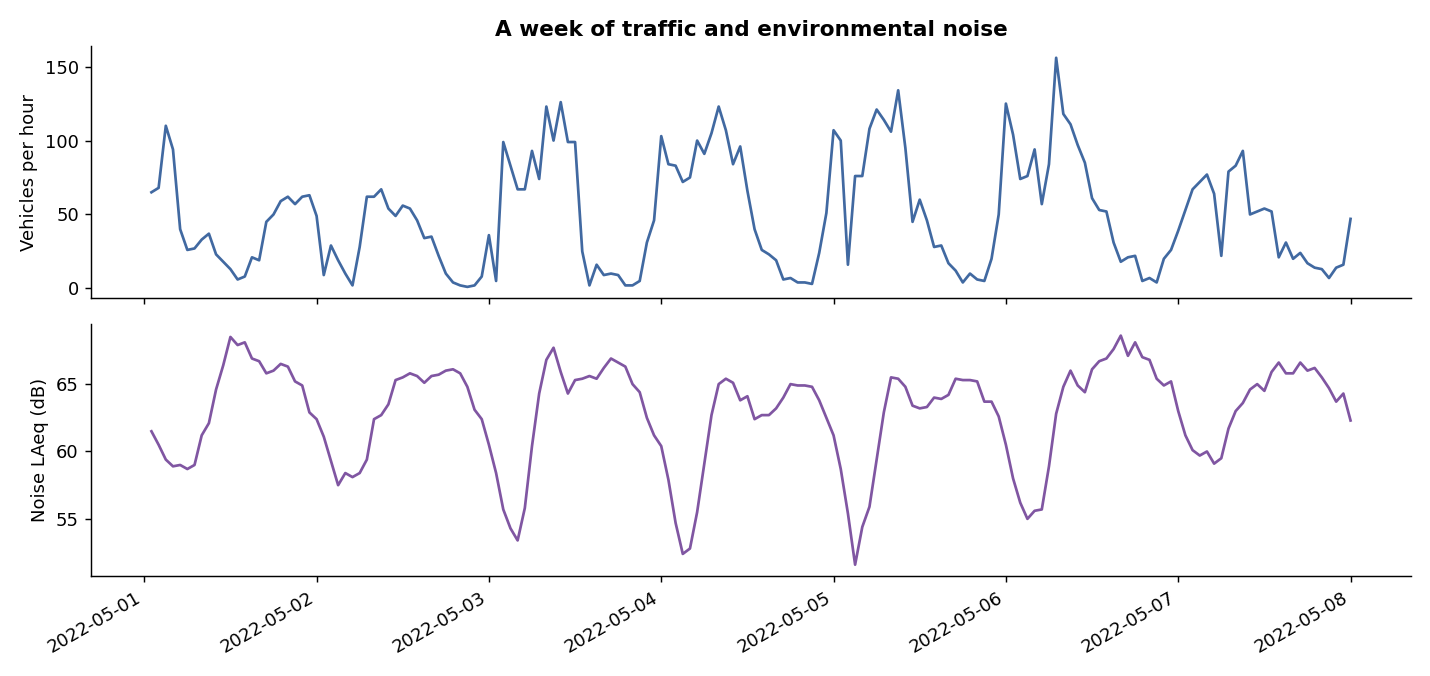

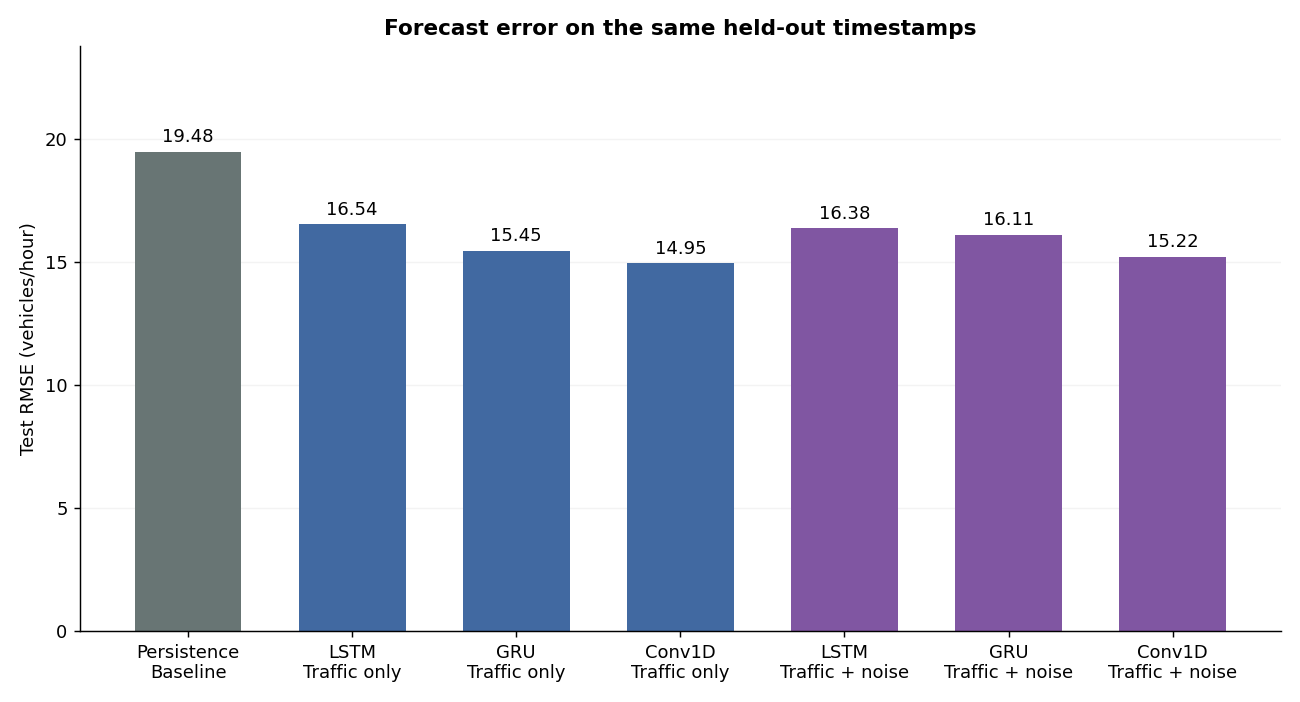

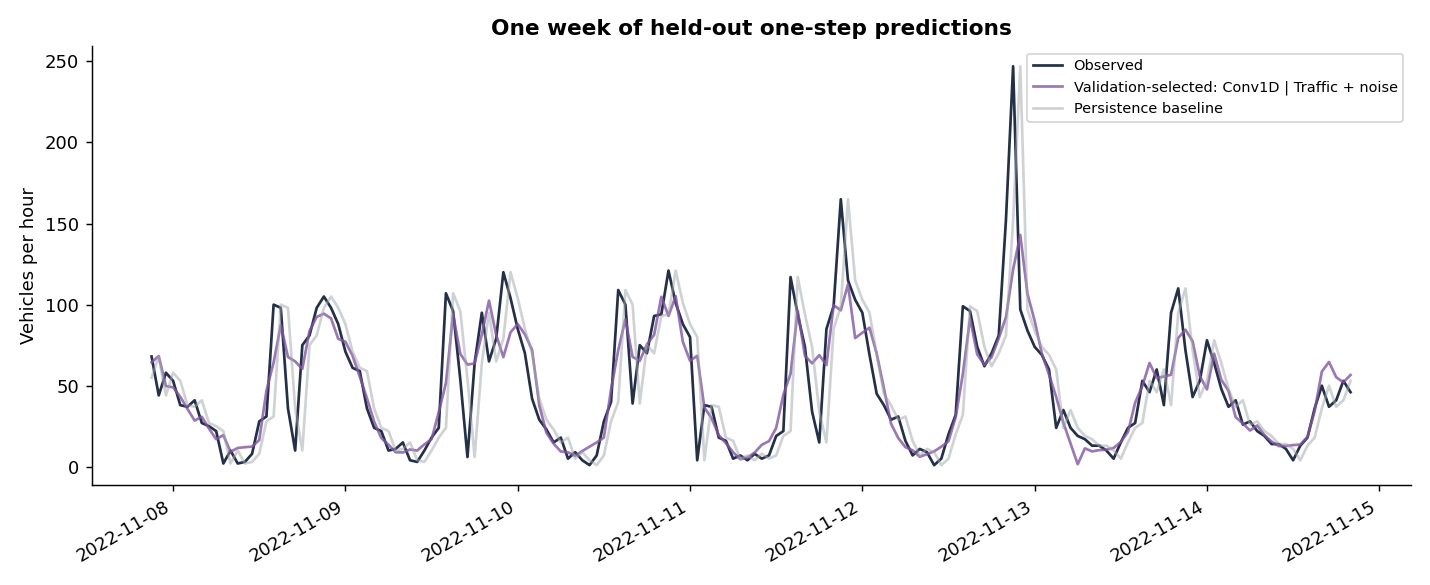

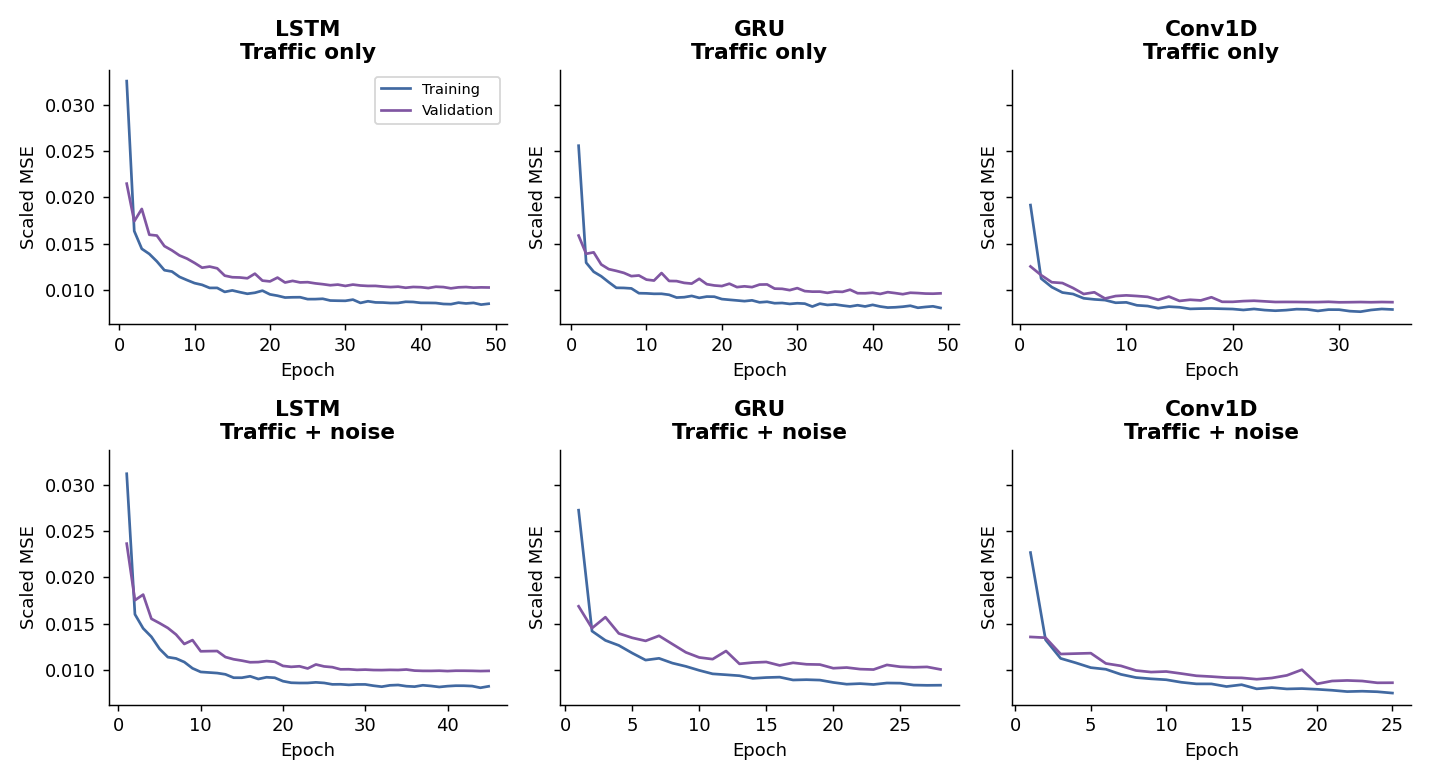

In [9]:
baseline = metrics.loc[metrics.Model.eq("Persistence")].iloc[0]
selected = metrics.loc[metrics.Validation_RMSE.idxmin()]
change = 100 * (baseline.RMSE - selected.RMSE) / baseline.RMSE
display(Markdown(f"**Selected by validation:** {selected.Model}, {selected.Inputs}. "
                 f"Test RMSE **{selected.RMSE:.2f}**, versus baseline **{baseline.RMSE:.2f}**. "
                 f"Relative test RMSE reduction: **{change:.1f}%** (negative means worse)."))
comparison = metrics.loc[metrics.Model.ne("Persistence")].pivot(index="Model", columns="Inputs", values="RMSE")
comparison["Change from adding noise (%)"] = 100 * (comparison["Traffic + noise"] / comparison["Traffic only"] - 1)
display(comparison.round(3))
print("Negative change means lower test error with noise. LSTM also differs in dropout.")
for figure in ["traffic_and_noise", "model_comparison", "test_predictions", "training_curves"]:
    display(Image(filename=str(ROOT / "figures" / f"{figure}.png")))

## 7. Check saved model reuse

Model checkpoints operate on **scaled** inputs and return **scaled** predictions. Reuse the matching saved scalers. The next cell reloads one checkpoint and confirms that its predictions match those reported in this run. Checkpoints for all six variants are saved; they do not need to be uploaded to GitHub.

In [10]:
import tensorflow as tf
saved = joblib.load(ROOT / "models/preprocessing.joblib")
restored = tf.keras.models.load_model(ROOT / "models/lstm_1features.keras", compile=False)
prepared = prepare_data(ROOT)
x_test = prepared["x"][prepared["masks"]["test"], :, :1]
scaled_prediction = restored(x_test[:10], training=False).numpy()
reloaded_prediction = saved["target_scaler"].inverse_transform(scaled_prediction).ravel()
reported = pd.read_csv(ROOT / "results/test_predictions.csv")["LSTM | Traffic only"].to_numpy()[:10]
np.testing.assert_allclose(reloaded_prediction, reported, rtol=1e-4, atol=1e-3)
print("Saved-model reload check passed.")

Saved-model reload check passed.


## Limitations and next steps

This is one detector, one test period and one seed. Missing-data assumptions and retained source-data limitations affect interpretation. The LSTM dropout difference prevents attributing its full performance difference solely to noise. GRU and Conv1D retain matched architectures between input variants.

Future work: seasonal baselines, several seeds, repeated temporal validation and additional locations. The current project evaluates raw next-hour counts; scores are not directly comparable with the old notebook's smoothed-target scores.